In [1]:
from torchdiffeq import odeint
from importlib import reload
import CNF
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from tqdm import tqdm
from IPython.display import display

DEVICE = "cpu"

In [2]:
FIELDS = 32
HIDDEN_LAYERS = 32
STEPS = 1000
SAVE_AFTER = 50
BATCH_SIZE = 64

In [3]:
reload(CNF)

<module 'CNF' from '/home/alekseyka/projects/science school/CNF.py'>

In [4]:
def get_batch(n: int):
    X, _ = make_circles(n, noise=0.06, factor=0.5)
    return torch.tensor(X, dtype=torch.float32, device=DEVICE)

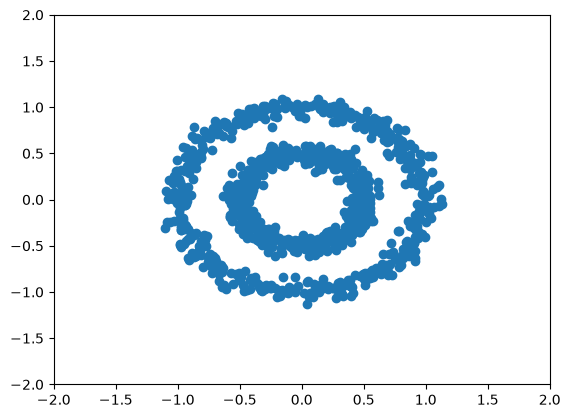

In [5]:
fig, ax = plt.subplots()

# Координаты сетки
X = get_batch(1000)
X = X.cpu().numpy()
x, y = X[:, 0], X[:, 1]
ax.scatter(x, y)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
# plt.colorbar()
plt.show()

In [6]:
reload(CNF)
# cpnf: CNF.Cpnf = CNF.Cpnf(2)
# cpnf.to(DEVICE)
hidden_features = HIDDEN_LAYERS
filds_num = FIELDS
cpnflist = torch.nn.ModuleList([CNF.Cpnf(2).to(DEVICE) for i in range(filds_num)])
time_gates = torch.nn.ModuleList([torch.nn.Sequential(torch.nn.Linear(1, hidden_features),
                                  torch.nn.Sigmoid(),
                                  torch.nn.Linear(hidden_features, 1)) for i in range(filds_num)])
cnf = CNF.CNF(fields=cpnflist, activations=time_gates)
wraped = CNF.Wraper(cnf)

In [7]:
Y, jac = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]], device=DEVICE), log_jac=True)
Y1 = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]], device=DEVICE))
Y, jac, Y1


(tensor([[0.9518, 1.9518],
         [0.6708, 1.0901],
         [1.3435, 1.8588]]),
 tensor([0.2633, 1.3149, 1.0234]),
 tensor([[0.9518, 1.9518],
         [0.6708, 1.0901],
         [1.3435, 1.8588]]))

In [8]:
def density(X):
    distribution = torch.distributions.MultivariateNormal(torch.zeros(2, device=DEVICE), torch.eye(2, device=DEVICE))
    Y, logprop = wraped.forward(X, log_jac=True)
    return distribution.log_prob(Y) - logprop

In [9]:
# fig, ax = plt.subplots()
def show_density(fig, ax):
    dist = 5
    # Координаты сетки
    x = torch.linspace(-dist, dist, 200)
    y = torch.linspace(-dist, dist, 200)

    X, Y = torch.meshgrid(x, y, indexing="xy")

    # Форма: (200 * 200, 2)
    points = torch.stack([X.flatten(), Y.flatten()], dim=1)
    # print(points, points.shape)
    points = points.detach().to(DEVICE)

    # Твоя функция принимает (batch_size, 2)
    Z = density(points)

    # Возвращаем результат к форме сетки
    Z = Z.reshape(200, 200)
    Z = torch.exp(Z)

#     plt.clf()
    im = ax.imshow(
    Z.cpu().numpy(),
            extent=[-dist, dist, -dist, dist],
            origin="lower",
            aspect="equal",
    )
    if hasattr(fig, "_cbar"):
        fig._cbar.update_normal(im)
    else:
        fig._cbar = fig.colorbar(im, ax=ax)
    # fig.colorbar(im, ax=ax)
#     plt.show()
def show_density_simple():
    ax, fig = plt.subplots()
    show_density(ax, fig)
    plt.show(fig)

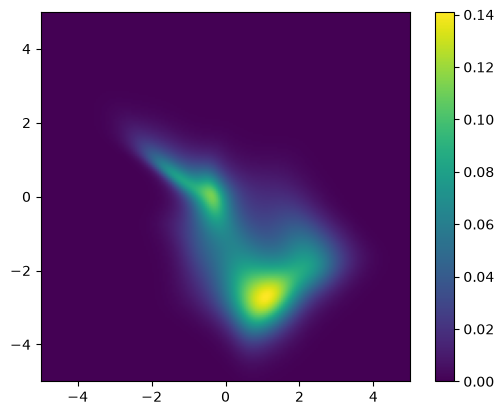

In [10]:
show_density_simple()

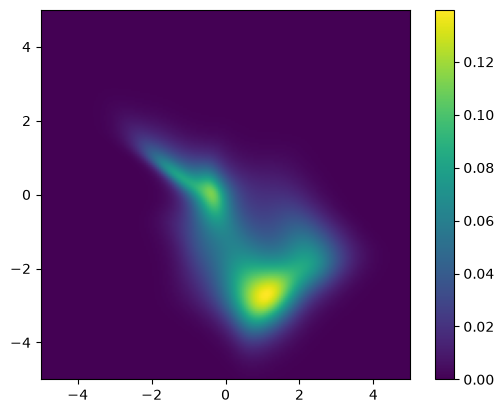

tensor(205.9833, grad_fn=<NegBackward0>)

  3%|▎         | 31/1000 [00:26<14:02,  1.15it/s]


KeyboardInterrupt: 

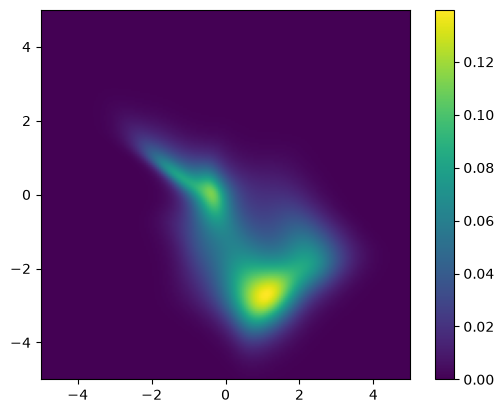

In [11]:
optimizer = torch.optim.Adam(wraped.field.parameters(), lr=0.0001)
step = 0
# history = []
fig, ax = plt.subplots()
out = display(fig, display_id=True)
loss = 0
out2 = display(loss, display_id=True)

for i in tqdm(range(STEPS)):
    X = get_batch(BATCH_SIZE)
    Y, log_jac = wraped.forward(X, True)
    Y.requires_grad_()
    loss = CNF.loss_function(2, Y, log_jac)
    optimizer.zero_grad()
    wraped.backward(Y, loss)
    optimizer.step()
    if step % SAVE_AFTER == 0:
        out2.update(loss)

        # fig.clear()
        show_density(fig, ax)
        out.update(fig)
        torch.save(cnf.state_dict(), "models/cnf.pt")
    step+=1
    